## Introduction to Data Science

#### University of Redlands - DATA 101
#### Prof: Joanna Bieri [joanna_bieri@redlands.edu](mailto:joanna_bieri@redlands.edu)
#### [Class Website: data101.joannabieri.com](https://joannabieri.com/data101.html)

---------------------------------------
# Homework Day 11
---------------------------------------

GOALS:

1. Understand Causal vs Experimental Studies
2. Do a more free form data analysis
3. Start doing your ethics reading

----------------------------------------------------------

This homework has **2 questions**, **10 exercises** and **1 essay response**.

In [222]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

# This stops a few warning messages from showing
pd.options.mode.chained_assignment = None 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [112]:
file_name = 'data/yougov-climate.csv'
DF = pd.read_csv(file_name,index_col=0)
DF

,The climate is changing and human activity is mainly responsible,"The climate is changing and human activity is partly responsible, together with other factors",The climate is changing but human activity is not responsible at all,The climate is not changing,Don't know
country,,,,,
GB,833,604,49,33,114
US,507,493,120,80,133


In the lecture we analyzed the following questions for the first column in the data:

### First question:

What percent of **all respondents** think the climate is changing and human activity is mainly responsible?  

### Second question:

What percent of **GB respondents** think the climate is changing and  human activity is mainly responsible?  

### Third Question

What percent of **US respondents** think the climate is changing and  human activity is mainly responsible?  

**Q1** Repeat the analysis from the lecture notes for one of the other columns/questions.

1. Percent total
2. Percent from GB
3. Percent from US

Talk about the conditional probability in this case:

eg. In a person is from ________ then there is a ________ probability that they believe _______. If a person answered _______ then they are more likley to be from ________. 

In [113]:
DF.loc['total'] = DF.sum(axis=0)
DF['total'] = DF.sum(axis=1)
DF


,The climate is changing and human activity is mainly responsible,"The climate is changing and human activity is partly responsible, together with other factors",The climate is changing but human activity is not responsible at all,The climate is not changing,Don't know,total
country,,,,,,
GB,833,604,49,33,114,1633
US,507,493,120,80,133,1333
total,1340,1097,169,113,247,2966


In [114]:
all_respondants = DF['total'].loc['total']
no_change = DF['The climate is not changing  ']['total']
float(no_change/all_respondants)


0.03809844908968307

1.3% of people believe that the climate is not changing.


In [115]:
US_respondants = DF['total'].loc['US']
no_change = DF['The climate is not changing  ']['US']
print(no_change/US_respondants)


0.06001500375093773


2% of US respondants believe that the climate is not changing.


## Berkeley admission data example

- Study carried out by the Graduate Division of the University of California, Berkeley in the early 70’s to evaluate whether there was a gender bias in graduate admissions.
- The data come from six departments. For confidentiality we'll call them A-F. 
- We have information on whether the applicant was male or female and whether they were admitted or rejected. This is an old study so only two binary classifications were used. 

### Here is the data


In [116]:
file_name = 'data/berkley.csv'
DF = pd.read_csv(file_name)
show(DF)

Loading ITables v2.6.2 from the internet... (need help?)


In [117]:
DF_melt = pd.melt(DF,id_vars=['Department'],var_name='MF',value_name='Number')
DF_melt


,Department,MF,Number
0,A,Male Yes,512
1,B,Male Yes,353
2,C,Male Yes,120
3,D,Male Yes,138
4,E,Male Yes,53
5,F,Male Yes,22
6,A,Male No,313
7,B,Male No,207
8,C,Male No,205
9,D,Male No,279


In [118]:
DF_melt['gender'] = DF_melt['MF'].apply(lambda x: x.split(' ')[0]).copy()
DF_melt['admitted'] = DF_melt['MF'].apply(lambda x: x.split(' ')[1]).copy()


In [119]:
DF_melt


,Department,MF,Number,gender,admitted
0,A,Male Yes,512,Male,Yes
1,B,Male Yes,353,Male,Yes
2,C,Male Yes,120,Male,Yes
3,D,Male Yes,138,Male,Yes
4,E,Male Yes,53,Male,Yes
5,F,Male Yes,22,Male,Yes
6,A,Male No,313,Male,No
7,B,Male No,207,Male,No
8,C,Male No,205,Male,No
9,D,Male No,279,Male,No


### Gender distribution by department

What can we say about the gender distribution if we look at the individual departments.

Start with our original "melted" data frame:

#### Lets pivot!

Pivot this data so that our departments become the column labels and our MF column becomes the index.

In [120]:
DF_dept = DF_melt.pivot(columns = 'Department', index = 'MF', values = 'Number')
DF_dept

Department,A,B,C,D,E,F
MF,,,,,,
Female No,19,8,391,244,299,317
Female Yes,89,17,202,131,94,24
Male No,313,207,205,279,138,351
Male Yes,512,353,120,138,53,22


**Q2** Calculate the proportions for the other departments. We did department A in the lecture. You can use the code from the lecture or come up with your own way to do this. You can do this one by one or try using a FOR loop.

Talk about what you see in these proportions. Which departments admit a large number of women? How do your number align with the visualization below?

In [121]:
my_columns = ['Number', 'gender', 'admitted']
DF_totals = DF_melt[my_columns].groupby(['gender','admitted'],as_index=False).sum()
DF_totals


,gender,admitted,Number
0,Female,No,1278
1,Female,Yes,557
2,Male,No,1493
3,Male,Yes,1198


In [122]:
DF_dept['B'].loc['Female Yes']
prob_female = DF_dept['B']['Female Yes']/(DF_dept['B']['Female Yes']+DF_dept['B']['Female No'])
prob_male=DF_dept['B']['Male Yes']/(DF_dept['B']['Male Yes']+DF_dept['B']['Male No'])
print(prob_female)
print(prob_male)



0.68
0.6303571428571428


### Here is a plot of the proportions data

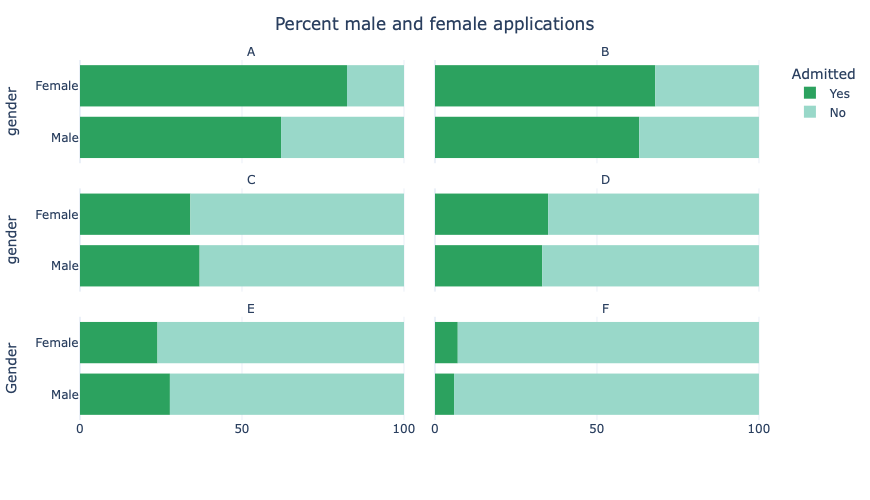

In [123]:
fig = px.histogram(DF_melt,
                   y='gender',
                   x='Number',
                   barnorm = "percent",
                   color='admitted',
                   facet_col='Department',
                   facet_col_wrap=2,
                   color_discrete_map = {'No':'#99d8c9','Yes':'#2ca25f'})

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[1]))
fig.update_xaxes(title_text='')

fig.update_layout(title='Percent male and female applications',
                  title_x=0.5,
                  template="plotly_white",
                  xaxis_title="",
                  yaxis_title="Gender",
                  legend_title='Admitted',
                  autosize=False,
                  width=800,
                  height=500)

fig.show()

------------------------
------------------------

## Homework - Exercises

** Homework content and data from Data Science in a Box - he-05-legos.Rmd

This week we'll do some data gymnastics to refresh and review what we learned over the past few weeks using (**simulated**) data from Lego sales in 2018 for a sample of customers who bought Legos in the US. This is different than the data we used on the Exam!


### Data

In [177]:
file_name = 'data/lego-sales.csv'
DF = pd.read_csv(file_name)
DF


,first_name,last_name,age,phone_number,set_id,number,theme,subtheme,year,name,pieces,us_price,image_url,quantity
0,Kimberly,Beckstead,24,216-555-2549,24701,76062,DC Comics Super Heroes,Mighty Micros,2018,Robin vs. Bane,77.0,9.99,http://images.brickset.com/sets/images/76062-1...,1
1,Neel,Garvin,35,819-555-3189,25626,70595,Ninjago,Rise of the Villains,2018,Ultra Stealth Raider,1093.0,119.99,http://images.brickset.com/sets/images/70595-1...,1
2,Neel,Garvin,35,819-555-3189,24665,21031,Architecture,NaN,2018,Burj Khalifa,333.0,39.99,http://images.brickset.com/sets/images/21031-1...,1
3,Chelsea,Bouchard,41,NaN,24695,31048,Creator,NaN,2018,Lakeside Lodge,368.0,29.99,http://images.brickset.com/sets/images/31048-1...,1
4,Chelsea,Bouchard,41,NaN,25626,70595,Ninjago,Rise of the Villains,2018,Ultra Stealth Raider,1093.0,119.99,http://images.brickset.com/sets/images/70595-1...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,Talise,Nieukirk,16,801-555-2343,24902,41556,Mixels,Series 7,2018,Tiketz,62.0,4.99,http://images.brickset.com/sets/images/41556-1...,2
616,Spencer,Morgan,28,784-555-3455,26041,41580,Mixels,Series 9,2018,Myke,63.0,4.99,NaN,2
617,Spencer,Morgan,28,784-555-3455,26060,5005051,Gear,Digital Media,2018,Friends of Heartlake City Girlz 4 Life,NaN,19.99,NaN,1
618,Amelia,Hageman,40,336-555-1950,24702,76063,DC Comics Super Heroes,Mighty Micros,2018,The Flash vs. Captain Cold,88.0,9.99,http://images.brickset.com/sets/images/76063-1...,2


### Exercises

* Answer the following questions using reproducible Python code.
* For each question, state your answer in a sentence, e.g. "In this sample, the first three common names of purchasers are ...".
* Note that the answers to all questions are within the context of this particular sample of sales, i.e. you shouldn't make inferences about the population of all Lego sales based on this sample.

-------------

1.  Describe what you see in the data set (variables, observations, etc)

2.  What are the three most common first names of purchasers?

3.  What are the three most common themes of Lego sets purchased?

4.  Among the most common theme of Lego sets purchased, what is the most common subtheme?

5.  Create data frames for each of the ages in the following categories: "18 and under", "19 - 25", "26 - 35", "36 - 50", "51 and over". HINT - use masks and create separate data frames -OR- create a new column with these categorical labels (more advanced).

6.  Which age group has purchased the highest number of Lego sets.

7.  Which age group has spent the most money on Legos?

8.  Which Lego theme has made the most money for Lego? HINT: Simpler than #5, just use a groupby()

9.  Which area code has spent the most money on Legos? In the US the area code is the first 3 digits of a phone number. HINT: You will need to split the phone number and get just the first three. You decided what to do about reporting the NaNs.

10.  Come up with a question you want to answer using these data, and write it down. Then, create a data visualization that answers the question, and explain how your visualization answers the question.

In [178]:
## 1. 14 variables and 620 observations

## 2. Jackson
DF['first_name'].value_counts()


first_name
Jackson       13
Joseph        11
Jacob         11
Michael       10
Kaitlyn        8
              ..
Gunnar         1
David          1
Lawrence       1
John'Dunae     1
Kimberly       1
Name: count, Length: 211, dtype: int64

In [179]:
## 3. Star Wars, Nexo Knights, and Gear/ Mixels
DF['theme'].value_counts()


theme
Star Wars                  75
Nexo Knights               64
Gear                       55
Mixels                     55
City                       45
Friends                    42
Ninjago                    38
Duplo                      35
Bionicle                   34
Creator                    25
DC Comics Super Heroes     22
Elves                      22
Marvel Super Heroes        19
Dimensions                 18
Disney Princess            15
The Angry Birds Movie      11
Technic                    10
Architecture               10
Minecraft                   9
Advanced Models             4
Ghostbusters                3
Seasonal                    3
Collectable Minifigures     3
Ideas                       2
Classic                     1
Name: count, dtype: int64

In [180]:
## 4.The Force Awakens
mask = DF['theme']== 'Star Wars'
DF[mask].value_counts('subtheme')


subtheme
The Force Awakens            15
Buildable Figures            11
Episode V                    10
MicroFighters                10
Battlefront                   7
Original Content              7
Episode III                   6
Rebels                        3
Seasonal                      3
Episode IV                    2
Ultimate Collector Series     1
Name: count, dtype: int64

In [181]:

## 5.
mask18 = DF['age'] <=18
mask1925 = (DF['age'] >19) & (DF['age'] <26)
mask2635 = (DF['age'] >25) & (DF['age'] <36)
mask3650 = (DF['age'] >35) & (DF['age'] <51)
mask51 = DF['age'] >50
DF.loc[mask18, 'age range'] = '18 and under'
DF.loc[mask1925, 'age range'] = '19 - 25'
DF.loc[mask2635, 'age range'] = '26 - 35'
DF.loc[mask3650, 'age range'] = '36 - 50'
DF.loc[mask51, 'age range'] = '51 and over'
DF

,first_name,last_name,age,phone_number,set_id,number,theme,subtheme,year,name,pieces,us_price,image_url,quantity,age range
0,Kimberly,Beckstead,24,216-555-2549,24701,76062,DC Comics Super Heroes,Mighty Micros,2018,Robin vs. Bane,77.0,9.99,http://images.brickset.com/sets/images/76062-1...,1,19 - 25
1,Neel,Garvin,35,819-555-3189,25626,70595,Ninjago,Rise of the Villains,2018,Ultra Stealth Raider,1093.0,119.99,http://images.brickset.com/sets/images/70595-1...,1,26 - 35
2,Neel,Garvin,35,819-555-3189,24665,21031,Architecture,NaN,2018,Burj Khalifa,333.0,39.99,http://images.brickset.com/sets/images/21031-1...,1,26 - 35
3,Chelsea,Bouchard,41,NaN,24695,31048,Creator,NaN,2018,Lakeside Lodge,368.0,29.99,http://images.brickset.com/sets/images/31048-1...,1,36 - 50
4,Chelsea,Bouchard,41,NaN,25626,70595,Ninjago,Rise of the Villains,2018,Ultra Stealth Raider,1093.0,119.99,http://images.brickset.com/sets/images/70595-1...,1,36 - 50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,Talise,Nieukirk,16,801-555-2343,24902,41556,Mixels,Series 7,2018,Tiketz,62.0,4.99,http://images.brickset.com/sets/images/41556-1...,2,18 and under
616,Spencer,Morgan,28,784-555-3455,26041,41580,Mixels,Series 9,2018,Myke,63.0,4.99,NaN,2,26 - 35
617,Spencer,Morgan,28,784-555-3455,26060,5005051,Gear,Digital Media,2018,Friends of Heartlake City Girlz 4 Life,NaN,19.99,NaN,1,26 - 35
618,Amelia,Hageman,40,336-555-1950,24702,76063,DC Comics Super Heroes,Mighty Micros,2018,The Flash vs. Captain Cold,88.0,9.99,http://images.brickset.com/sets/images/76063-1...,2,36 - 50


In [182]:
## 6.
DF.value_counts('age range')


age range
36 - 50         216
26 - 35         183
19 - 25         119
51 and over      62
18 and under     30
Name: count, dtype: int64

In [196]:
# 7.
my_columns = ['age range', 'us_price']
DF_price = DF[my_columns]
show(DF_price.groupby('age range').sum('us_price'))


Loading ITables v2.6.2 from the internet... (need help?)


In [203]:
## 8. Ghostbusters - Firehouse Headquarters
DF['profit'] = DF['us_price'] * DF['quantity']
DF.sort_values('profit', ascending = False)


,first_name,last_name,age,phone_number,set_id,number,theme,subtheme,year,name,pieces,us_price,image_url,quantity,age range,profit
473,Jennifer,Dana,26,956-555-9719,25597,75827,Ghostbusters,NaN,2018,Firehouse Headquarters,4634.0,349.99,http://images.brickset.com/sets/images/75827-1...,2,26 - 35,699.98
53,Cecilia,Mauro,50,NaN,25921,75157,Star Wars,Rebels,2018,Captain Rex's AT-TE,972.0,119.99,http://images.brickset.com/sets/images/75157-1...,3,36 - 50,359.97
148,Kaitlyn,Degeer,24,316-555-7890,24994,10251,Advanced Models,Modular Buildings,2018,Brick Bank,2380.0,169.99,http://images.brickset.com/sets/images/10251-1...,2,19 - 25,339.98
563,Elias,Garrett,50,832-555-9165,24915,60130,City,Police,2018,Prison Island,754.0,89.99,http://images.brickset.com/sets/images/60130-1...,3,36 - 50,269.97
42,Hector,Collins,20,340-555-2508,24627,75098,Star Wars,Ultimate Collector Series,2018,Assault on Hoth,2144.0,249.99,http://images.brickset.com/sets/images/75098-1...,1,19 - 25,249.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Cameron,Rodriguez,48,325-555-1926,25910,30347,City,Fire,2018,Fire Car,53.0,3.99,http://images.brickset.com/sets/images/30347-1...,1,36 - 50,3.99
389,Seth,Foley,24,NaN,25594,71011,Collectable Minifigures,Series 15,2018,LEGO Minifigures - Series 15 - Sealed Box,NaN,3.99,http://images.brickset.com/sets/images/71011-1...,1,19 - 25,3.99
86,Janay,Gienapp,63,774-555-2102,25893,30349,City,NaN,2018,Sports Car,47.0,3.99,http://images.brickset.com/sets/images/30349-1...,1,51 and over,3.99
201,Daianaira,Joseph,26,714-555-9762,25594,71011,Collectable Minifigures,Series 15,2018,LEGO Minifigures - Series 15 - Sealed Box,NaN,3.99,http://images.brickset.com/sets/images/71011-1...,1,26 - 35,3.99


In [220]:
## 9. 956
DF_new = DF[DF['phone_number'].notnull()]
DF_new['area code'] = DF_new['phone_number'].apply(lambda x: x.split('-')[0]).copy()
DF_new.groupby('area code').sum('profit').sort_values('profit', ascending = False)


,age,set_id,year,pieces,us_price,quantity,profit
area code,,,,,,,
956,52,50288,4036,4758.0,359.98,4,719.96
973,220,151986,12108,3802.0,444.94,9,684.91
567,349,224383,18162,2825.0,326.91,14,549.86
281,237,228148,18162,2184.0,434.91,10,464.90
316,184,201724,16144,2985.0,257.92,10,437.90
...,...,...,...,...,...,...,...
509,33,24701,2018,77.0,9.99,1,9.99
308,20,24757,2018,93.0,9.99,1,9.99
216,24,24701,2018,77.0,9.99,1,9.99


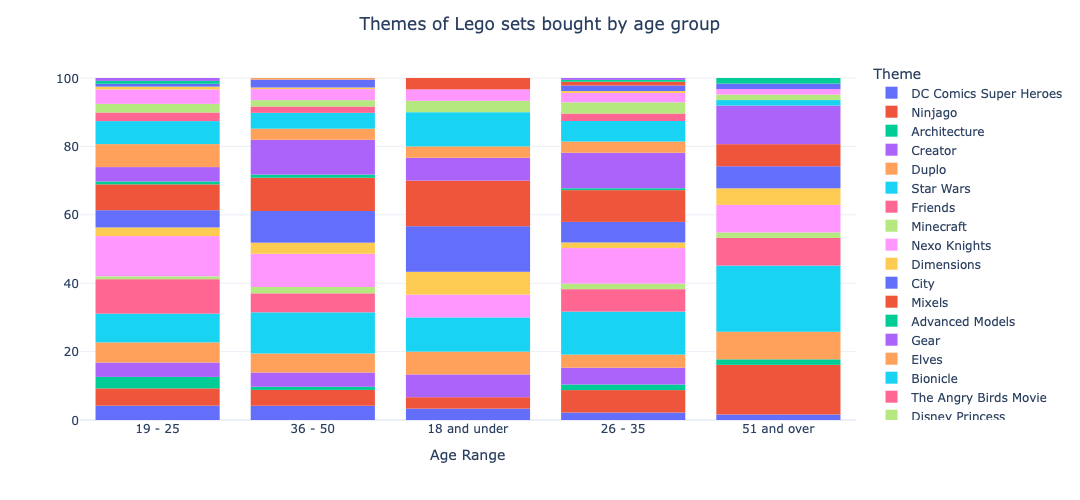

In [227]:
## 10. Data Visualization - What themes are each age group buying?

fig = px.histogram(DF,
                   x='age range',
                   barnorm = "percent",
                   color='theme')

fig.update_layout(title='Themes of Lego sets bought by age group',
                  title_x=0.5,
                  template="plotly_white",
                  xaxis_title="Age Range",
                  yaxis_title="",
                  legend_title='Theme',
                  autosize=False,
                  width=800,
                  height=500)


fig.show()

## Essay Response

Give a brief report on what you are reading and what you have learned so far. If you chose your own articles please insert a link to the articles. If you chose a book, please give the book title and author.

1. What drew you to the book/articles
2. What have you learned so far.

eg. In the first chapter of the book the author talks about..... or My first article discusses..... or I disagree with what the author is saying so far.... or I really like what I am learning about because....

I read through more of Data Feminism and Weapons of Math Destruction and an article in Actuary - a magazine geared towards the Actuary profession. I started both Data Feminism and Weapons of Math Destruction in another data course, and was really drawn to the idea of equity through data and how little consideration was given early on in the creation of a lot our data collection practices world wide. I find it really fascinating how on the cutting edge equity in Big Data still is, and how data scientists have a strong responsibility to the oublic in how it operates. It is easy to contribute to the black box of deception so prevelant in the industry and how there is still so much work to be done, especially when it comes to accounting for intersectionality and diversity of experience while maintaining predictive modeling. There is a fine line in accounting for outliers and using diverse experience in your training data- regardless of the algorithm. I paired this reading with the article titled "Fair trade-off: balancing algorithms and ethics" and it outlined the narrow path that actuaries are taking with the increase of data science in the profession. Specifically, this article echos the same sentiments around the responsibility to create equity in the algorthims, and balancing that with the need for predictable models and the ability to use them for general public use. Actuaries are in a position of great power in this way - they determine rates of insurance and liability for many people and firms, across industries. This call for ethical use of data and push towards eliminating bias in work creates a big opportunity for deception. I have learned a lot in my accounting ethics class about how much someone can exploit very small gaps in order to exploit people for profit, and this feels like a large gap. As this level of data and the speed in which we use it will continue to become more normal, and people will learn the way in which to navigate these fairly and with deferance, but it currently sits at what feels like a wide open field for exploration and opportunity in the data science field through the lens of actuary science.